# Example notebook for Ensemble of 2D (lon-lat) diagnostic 2-meter temperature 

##### This notebook demonsterates how the ensemble module can be used for 2D (lon-lat) 2 meter temperature data from a single ensemble or multi-model ensemble memebers

In [1]:
import glob

from aqua.diagnostics import EnsembleLatLon, PlotEnsembleLatLon, merge_from_data_files

/home/b/b383755/miniforge3/envs/aqua-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading IFS-FESOM and IFS-NEMO 2D maps computed by AQUA diagnostics
file_list = glob.glob(
    "/work/ab0995/a270260/pre_computed_aqua_analysis/*/historical-1990/atmglobalmean/netcdf/atmglobalmean.statistics_maps.2t.*_historical-1990.nc"
)
file_list.sort()
# data paths on lumi
# IFS-NEMO: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-NEMO/historical-1990/atmglobalmean/netcdf/atmglobalmean.statistics_maps.2t.IFS-NEMO_historical-1990.nc
# IFS-FESOM: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-FESOM/historical-1990/atmglobalmean/netcdf/atmglobalmean.statistics_maps.2t.IFS-FESOM_historical-1990.nc

In [3]:
file_list

['/work/ab0995/a270260/pre_computed_aqua_analysis/IFS-FESOM/historical-1990/atmglobalmean/netcdf/atmglobalmean.statistics_maps.2t.IFS-FESOM_historical-1990.nc',
 '/work/ab0995/a270260/pre_computed_aqua_analysis/IFS-NEMO/historical-1990/atmglobalmean/netcdf/atmglobalmean.statistics_maps.2t.IFS-NEMO_historical-1990.nc']

In [4]:
# # Without assigning names to the models
# # merging the dataset along the dimension ens_dim
# # ens_dim="ensemble" name can be changed.
# # It should remain consistent with the ensemble name for the EnsembleLatLon class variable
# ens_dataset = retrieve_merge_ensemble_data(variable='2t', data_path_list=file_list, log_level = "WARNING",ens_dim="ensemble")

In [4]:
# Assiging names to each model in the following function
# merging the dataset along the dimension ens_dim
# ens_dim="ensemble" name can be changed.
# It should remain consistent with the ensemble name for the EnsembleLatLon class variable
ens_dataset = merge_from_data_files(
    variable="2t", model_names=["IFS-FESOM", "IFS-NEMO"], data_path_list=file_list, loglevel="WARNING", ens_dim="ensemble"
)

In [6]:
ens_dataset

<xarray.Dataset> Size: 1MB
Dimensions:   (ensemble: 2, lat: 180, lon: 361)
Coordinates:
  * ensemble  (ensemble) int64 16B 0 1
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
    model     (ensemble) <U9 72B 'IFS-FESOM' 'IFS-NEMO'
Data variables:
    2t        (ensemble, lat, lon) float64 1MB 228.9 228.9 228.9 ... 255.7 255.7
Attributes: (12/23)
    GRIB_paramId:                    167
    long_name:                       2 metre temperature
    GRIB_stepUnits:                  1
    GRIB_gridDefinitionDescription:  150
    GRIB_typeOfLevel:                heightAboveGround
    standard_name:                   air_temperature
    ...                              ...
    GRIB_shortName:                  2t
    GRIB_units:                      K
    GRIB_dataType:                   fc
    model_label:                     IFS-FESOM_historical-1990
    description:                     Dataset merged along ensemble for ensemb...
    model:                           ['IFS-FESOM', 'IFS-NEMO']

In [5]:
atmglobalmean_ens = EnsembleLatLon(var="2t", dataset=ens_dataset, ensemble_dimension_name="ensemble")

In [6]:
atmglobalmean_ens.run()

{'mean_plot': [<Figure size 1100x850 with 2 Axes>,
  <GeoAxes: title={'center': 'Map of 2t for Ensemble Multi-Model mean'}, xlabel='Longitude', ylabel='Latitude'>],
 'std_plot': [<Figure size 1100x850 with 2 Axes>,
  <GeoAxes: title={'center': 'Map of 2t for Ensemble Multi-Model standard deviation'}, xlabel='Longitude', ylabel='Latitude'>]}

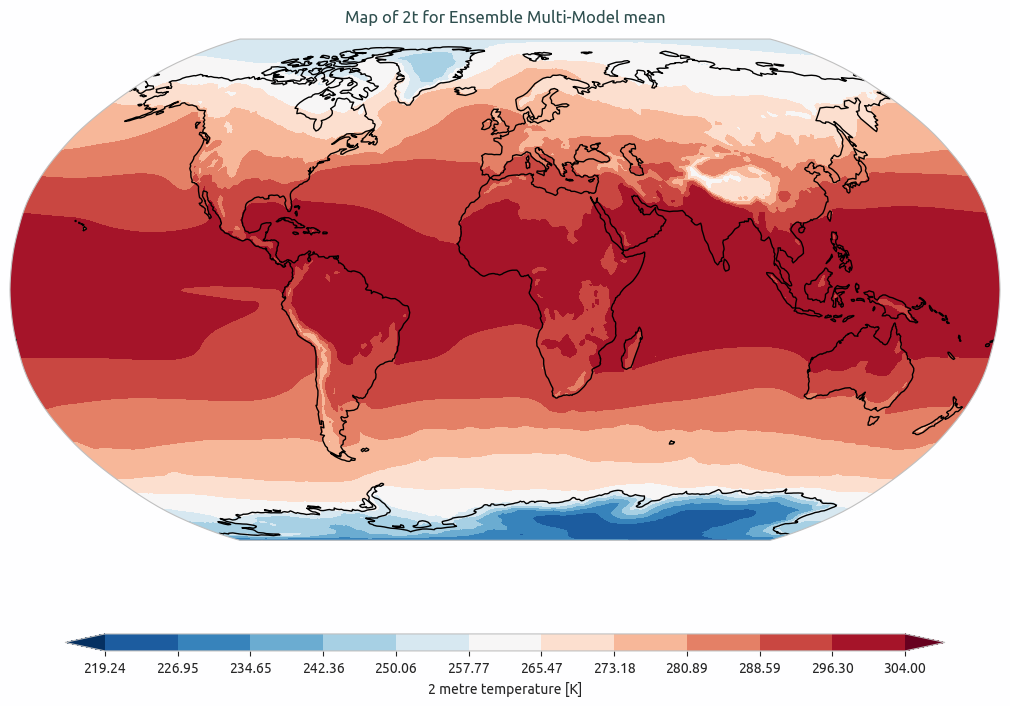

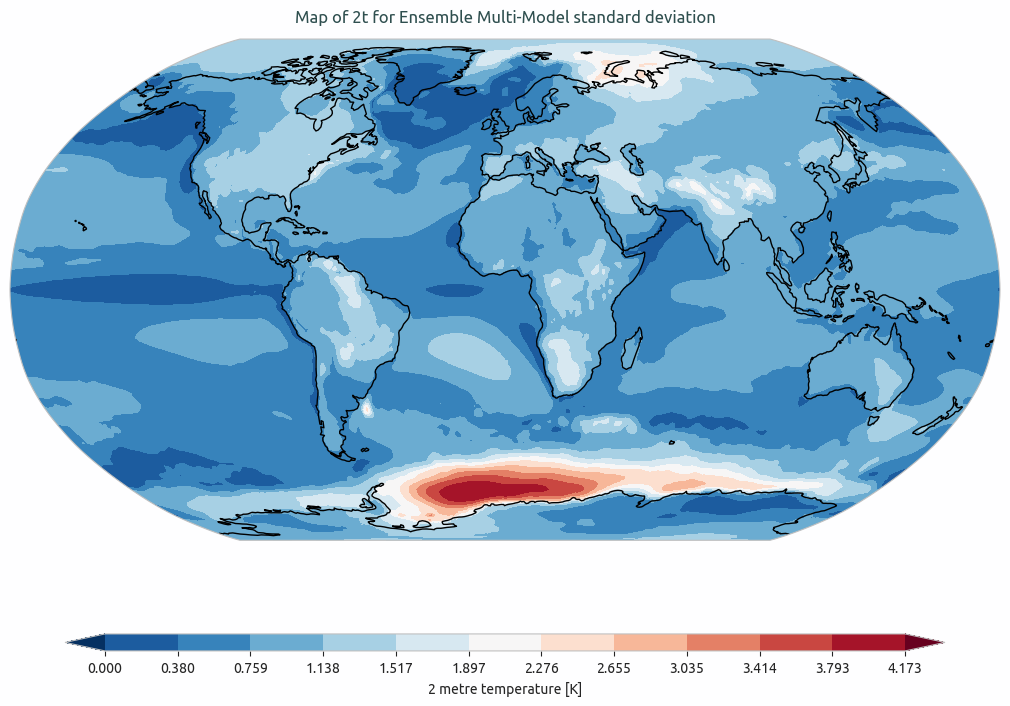

In [7]:
# PlotEnsembleLatLon class
var = "2t"
plot_class_arguments = {
    "model_list": ["IFS-FESOM", "IFS-NEMO"],
}

ens_latlon_plot = PlotEnsembleLatLon(
    **plot_class_arguments,
)

plot_arguments = {
    "var": var,
    "save_format": ["png", "pdf", "svg"],
    "title_mean": "Map of 2t for Ensemble Multi-Model mean",
    "title_std": "Map of 2t for Ensemble Multi-Model standard deviation",
    "cbar_label": "2 meter temperature in K",
    "dataset_mean": atmglobalmean_ens.dataset_mean,
    "dataset_std": atmglobalmean_ens.dataset_std,
}

ens_latlon_plot.plot(**plot_arguments)

In [10]:
atmglobalmean_ens.dataset

<xarray.Dataset> Size: 1MB
Dimensions:   (ensemble: 2, lat: 180, lon: 361)
Coordinates:
  * ensemble  (ensemble) int64 16B 0 1
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
    model     (ensemble) <U9 72B 'IFS-FESOM' 'IFS-NEMO'
Data variables:
    2t        (ensemble, lat, lon) float64 1MB 228.9 228.9 228.9 ... 255.7 255.7
Attributes: (12/23)
    GRIB_paramId:                    167
    long_name:                       2 metre temperature
    GRIB_stepUnits:                  1
    GRIB_gridDefinitionDescription:  150
    GRIB_typeOfLevel:                heightAboveGround
    standard_name:                   air_temperature
    ...                              ...
    GRIB_shortName:                  2t
    GRIB_units:                      K
    GRIB_dataType:                   fc
    model_label:                     IFS-FESOM_historical-1990
    description:                     Dataset merged along ensemble for ensemb...
    model:                           ['IFS-FESOM', 'IFS-NEMO']

In [11]:
atmglobalmean_ens.dataset_std

<xarray.DataArray '2t' (lat: 180, lon: 361)> Size: 520kB
array([[1.06380575, 1.0337967 , 1.03375562, ..., 1.09381116, 1.09379607,
        1.06380575],
       [1.07469302, 1.05811012, 1.05820149, ..., 1.09133029, 1.09133664,
        1.07469302],
       [1.07203348, 1.045261  , 1.04493347, ..., 1.09807046, 1.09836346,
        1.07203348],
       ...,
       [1.35584519, 1.37381886, 1.37344788, ..., 1.33741245, 1.33752601,
        1.35584519],
       [1.34816559, 1.36040753, 1.36020764, ..., 1.33587774, 1.33582135,
        1.34816559],
       [1.34365779, 1.35148137, 1.35145462, ..., 1.33580407, 1.33581059,
        1.34365779]], shape=(180, 361))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
Attributes:
    AQUA diagnostic:  EnsembleLatLon
    AQUA catalog:     ['ensemble_catalog']
    model:            ['ensemble_model']
    experiment:       ['ensemble_exp']
    description:      ensemble EnsembleLatLon for ['ensemble_catalog'] and ['...